In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def get_rms(data):
	data = np.array(data)
	data = data - (sum(data)/len(data))
	s = data**2
	ms = sum(s)/len(s)
	rms = np.sqrt(ms)
	return rms

def avg_peak_height(data):
	# Extract peak heights
	y = []
	x = []
	for i in range(len(data) - 5):
		if data[i] >= max(data[i+1], data[i+2], data[i-1], data[i-2]):
			y.append(data[i])
			x.append(i)
	return sum(y)/len(y)

In [3]:
a = np.arange(1, 10, 1)
datas = {}
for i in a:
	data = np.loadtxt(rf"C:\\Users\\BaughLaflamme\\Desktop\\Qblox Master Folder\\Cluster\\Testing\Tests\\Output linearity tests\\RF output linearity test\\data\\out0_ch1_amp0_{i}.txt", skiprows = 3)
	datas[round(i/10, 1)] = data[21000:170000]
datas[1.0] = np.loadtxt(rf"C:\\Users\\BaughLaflamme\\Desktop\\Qblox Master Folder\\Cluster\\Testing\Tests\\Output linearity tests\\RF output linearity test\\data\\out0_ch1_amp1.txt", skiprows = 3)[21000:170000]

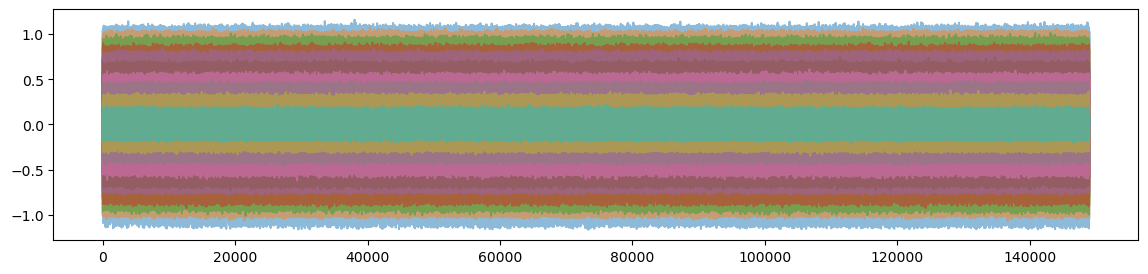

In [4]:
fig, ax = plt.subplots(1, 1, figsize= (14, 3))
b = reversed(np.arange(0.1, 1, 0.1))
rmss = []
avg_peaks = []
ax.plot(datas[1.0], alpha = 0.5)
rmss.append(get_rms(datas[1.0]))
avg_peaks.append(avg_peak_height(datas[1.0]))
for i in b:
	rmss.append(get_rms(datas[round(i, 1)]))
	avg_peaks.append(avg_peak_height(datas[round(i, 1)]))
	ax.plot(datas[round(i, 1)], alpha = 0.5)
plt.show()
amps = np.array([1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1])

In [5]:
fit_rms = np.polyfit(amps, rmss, 1)
yl_rms = fit_rms[0]*amps + fit_rms[1]

fit_peak = np.polyfit(amps, avg_peaks, 1)
yl_peak = fit_peak[0]*amps + fit_peak[1]

quad_rms = np.polyfit(amps, rmss, 2)
yq_rms = quad_rms[0]*(amps**2) + quad_rms[1]*amps + quad_rms[2]

quad_peak = np.polyfit(amps, avg_peaks, 2)
yq_peak = quad_peak[0]*(amps**2) + quad_peak[1]*amps + quad_peak[2]

In [6]:
# Getting R**2 value for each fit
def r_squared(data, fit):
	mean = sum(data) / len(data)
	sstot = sum((data-mean)**2)
	ssres = sum((data - fit)**2)
	return 1 - (ssres/sstot)

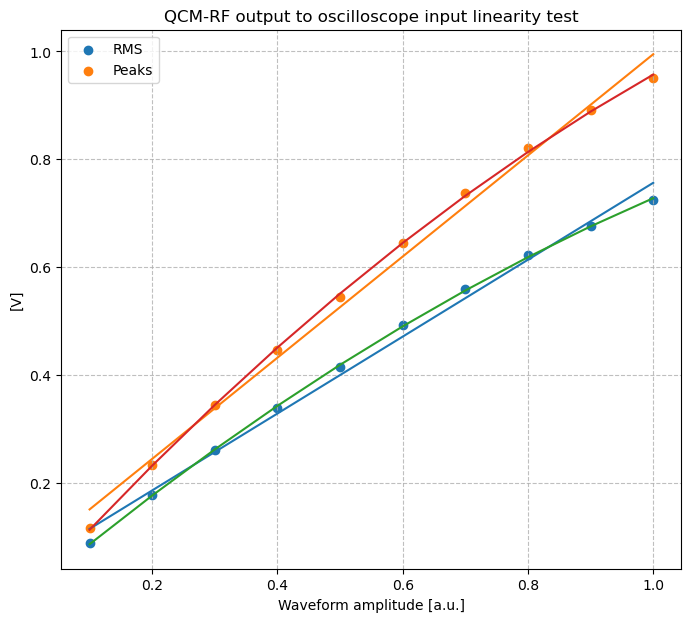

RMS linear fit R**2:     0.993
RMS quadratic fit R**2:  0.9998
Peak linear fit R**2:    0.993
Peak quadratic fit R**2: 0.9997



In [7]:
fig, ax = plt.subplots(1, 1, figsize = (8, 7))
ax.scatter(amps, rmss, label = "RMS")
ax.scatter(amps, avg_peaks, label = "Peaks")
ax.grid(ls = "--", alpha = 0.8)
ax.plot(amps, yl_rms)
ax.plot(amps, yl_peak)
ax.plot(amps, yq_rms)
ax.plot(amps, yq_peak)
ax.set_title("QCM-RF output to oscilloscope input linearity test")
ax.set_ylabel("[V]")
ax.set_xlabel("Waveform amplitude [a.u.]")
plt.legend()
plt.show()

print("RMS linear fit R**2:     {:.3}\n".format(r_squared(rmss, yl_rms)) +
	  "RMS quadratic fit R**2:  {:.4}\n".format(r_squared(rmss, yq_rms)) + 
	  "Peak linear fit R**2:    {:.3}\n".format(r_squared(avg_peaks, yl_peak)) +
	  "Peak quadratic fit R**2: {:.4}\n".format(r_squared(avg_peaks, yq_peak)))